## original analysis
original means to take `combined_samples_analyzed_one_canvas_labeled.ipynb` and redo trajectory - not from the `trajectory.py` script

In [66]:
import scanpy as sc
import cellrank as cr
from cellrank.kernels import RealTimeKernel
from moscot.problems.time import TemporalProblem
import matplotlib.pyplot as plt
from shapely import wkt
import geopandas as gpd
import scanpy.external as sce

In [67]:
adata = sc.read('../../combined_samples_analyzed_one_canvas_labeled.h5ad')
adata

AnnData object with n_obs × n_vars = 175494 × 18262
    obs: 'sample', 'instance_id', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden_harmony_0.6', 'leiden_harmony_0.7', 'cell_type', 'cell_type_labels', 'ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-', 'ebf2_sox9_col2a1', 'fpdev_reclustered_leiden_0.4', 'fpdev_reclustered_leiden_0.5', 'fpdev_reclustered_leiden_0.6', 'tdtom_reclustered_leiden_0.4', 'tdtom_reclustered_leiden_0.5', 'tdtom_reclustered_leiden_0.6', 'pdgfra', 'array_col', 'array_row', 'geometry', 'timepoints', 'tissue', 'cell_type_tdtom_0.4', 'pdgfra+', 'ebf2_sox9_pdgfra', 'pdgfra_cell_types', 'tdtom_0.6_cell_types', 'tdtomato+', 'pdgfra+_tdtomato+'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'cell_type_tdtom_0.6_colors', 'ebf2_sox9_col2a1_colo

In [69]:
adata.obs['geometry'] = adata.obs['geometry'].apply(wkt.loads)
shapes = gpd.GeoDataFrame(adata.obs, geometry='geometry')

<Axes: >

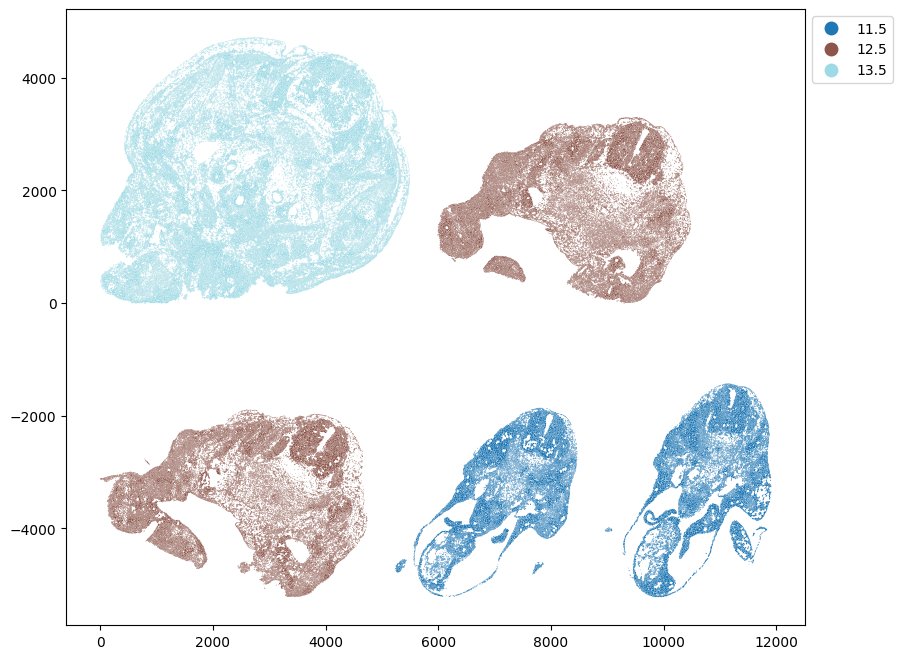

In [70]:
fig, ax = plt.subplots(figsize=(10, 8))
shapes.plot(column='timepoints', cmap='tab20', ax=ax, legend=True, legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})

<Axes: >

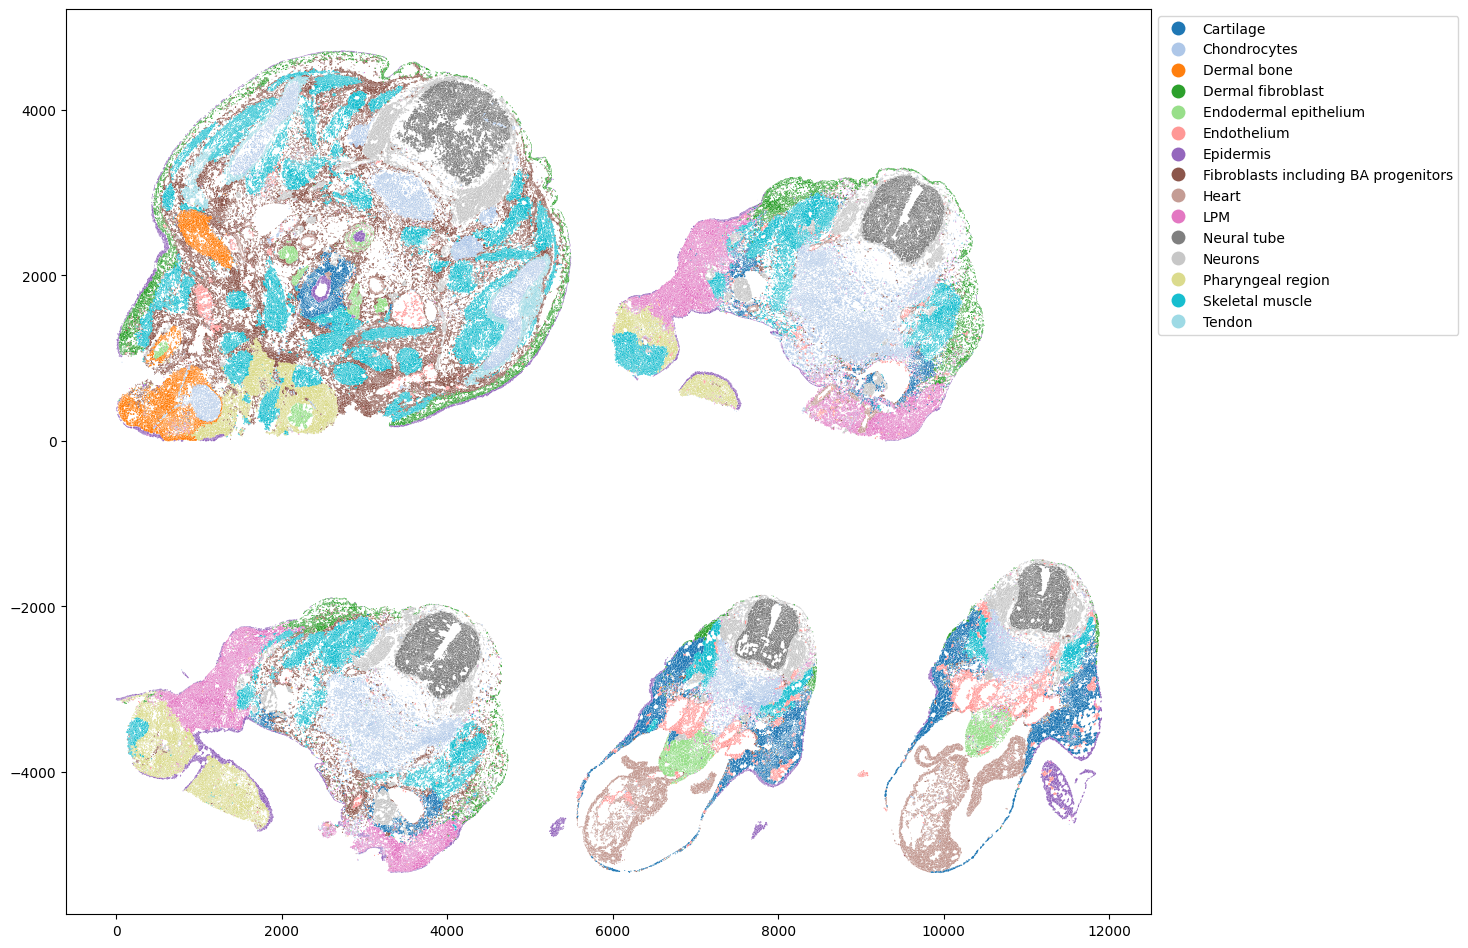

In [71]:
fig, ax = plt.subplots(figsize=(14, 12))
shapes.plot(column='cell_type_labels', cmap='tab20', ax=ax, legend=True, legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})

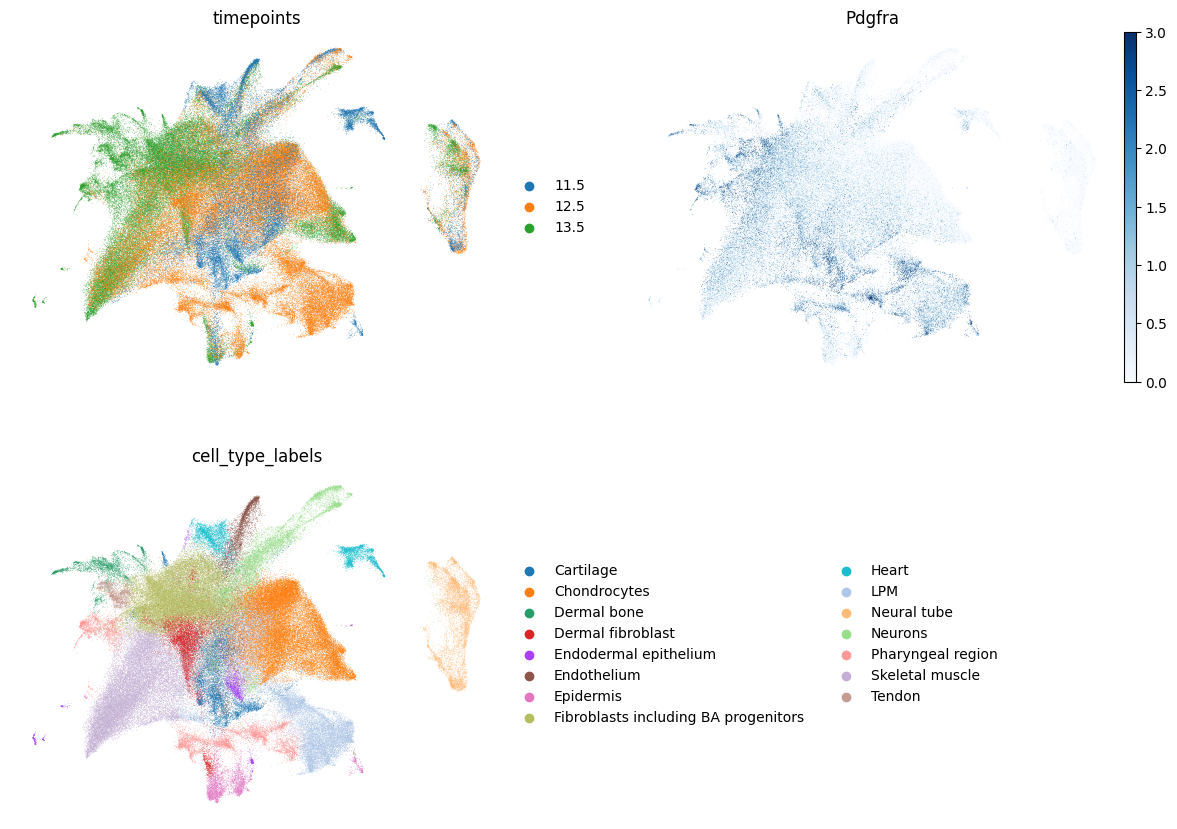

In [90]:
sc.pl.umap(adata, color=['timepoints', 'Pdgfra', 'cell_type_labels'], frameon=False, ncols=2, color_map='Blues', vmax=3)

## see marker genes expressions

In [ ]:
marker_genes = ['Krt5', 'Krt14', 'Cdh5', 'Kdr', 'Osr2', 'Crabp1', 'Twist2', 'Acta2', 'Tagln', 'Col2a1', 'Cldn11', 'Foxc1', 'Scx', 'Tnmd', 'Pparg', 'Cebpa', 'Pecam1', 'Pdgfra']
sc.pl.dotplot(adata, marker_genes, groupby='cell_type_labels', standard_scale='var')

In [ ]:
# epidermis markers: Krt5, Krt14
gene = ['Krt5', 'Krt14']

for g in gene:
    gene_idx = adata.var_names.get_loc(g)
    shapes['expr'] = adata.X[:, gene_idx].toarray().flatten()
    fig, ax = plt.subplots(figsize=(10, 8))
    shapes.plot(column='expr', cmap='Reds', ax=ax, legend=True, vmax=1)
    ax.set_title(g)
    plt.show()

In [ ]:
# endothelium markers: Cdh5, Kdr
gene = ['Kdr', 'Cdh5']

for g in gene:
    gene_idx = adata.var_names.get_loc(g)
    shapes['expr'] = adata.X[:, gene_idx].toarray().flatten()
    fig, ax = plt.subplots(figsize=(10, 8))
    shapes.plot(column='expr', cmap='Reds', ax=ax, legend=True, vmax=1)
    ax.set_title(g)
    plt.show()

In [ ]:
# MCT markers
gene = ['Osr2', 'Crabp1']

for g in gene:
    gene_idx = adata.var_names.get_loc(g)
    shapes['expr'] = adata.X[:, gene_idx].toarray().flatten()
    fig, ax = plt.subplots(figsize=(10, 8))
    shapes.plot(column='expr', cmap='Reds', ax=ax, legend=True, vmax=1)
    ax.set_title(g)
    plt.show()

In [ ]:
# dermis markers: Twist2
gene = ['Twist2']
gene_idx = adata.var_names.get_loc(g)
shapes['expr'] = adata.X[:, gene_idx].toarray().flatten()
fig, ax = plt.subplots(figsize=(10, 8))
shapes.plot(column='expr', cmap='Reds', ax=ax, legend=True, vmax=1)
ax.set_title(g)
plt.show()

In [ ]:
# 
gene = ['Twist2']
gene_idx = adata.var_names.get_loc(g)
shapes['expr'] = adata.X[:, gene_idx].toarray().flatten()
fig, ax = plt.subplots(figsize=(10, 8))
shapes.plot(column='expr', cmap='Reds', ax=ax, legend=True, vmax=1)
ax.set_title(g)
plt.show()

## pdgfra

### pdgfra+ cells

In [76]:
mask_pdgfra = adata.obs['pdgfra+'] == True
pdgfra = adata[mask_pdgfra].copy()
pdgfra

AnnData object with n_obs × n_vars = 43076 × 18262
    obs: 'sample', 'instance_id', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden_harmony_0.6', 'leiden_harmony_0.7', 'cell_type', 'cell_type_labels', 'ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-', 'ebf2_sox9_col2a1', 'fpdev_reclustered_leiden_0.4', 'fpdev_reclustered_leiden_0.5', 'fpdev_reclustered_leiden_0.6', 'tdtom_reclustered_leiden_0.4', 'tdtom_reclustered_leiden_0.5', 'tdtom_reclustered_leiden_0.6', 'pdgfra', 'array_col', 'array_row', 'geometry', 'timepoints', 'tissue', 'cell_type_tdtom_0.4', 'pdgfra+', 'ebf2_sox9_pdgfra', 'pdgfra_cell_types', 'tdtom_0.6_cell_types', 'tdtomato+', 'pdgfra+_tdtomato+'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'cell_type_tdtom_0.6_colors', 'ebf2_sox9_col2a1_color

In [77]:
shapes_pdgfra = gpd.GeoDataFrame(pdgfra.obs, geometry='geometry')

<Axes: >

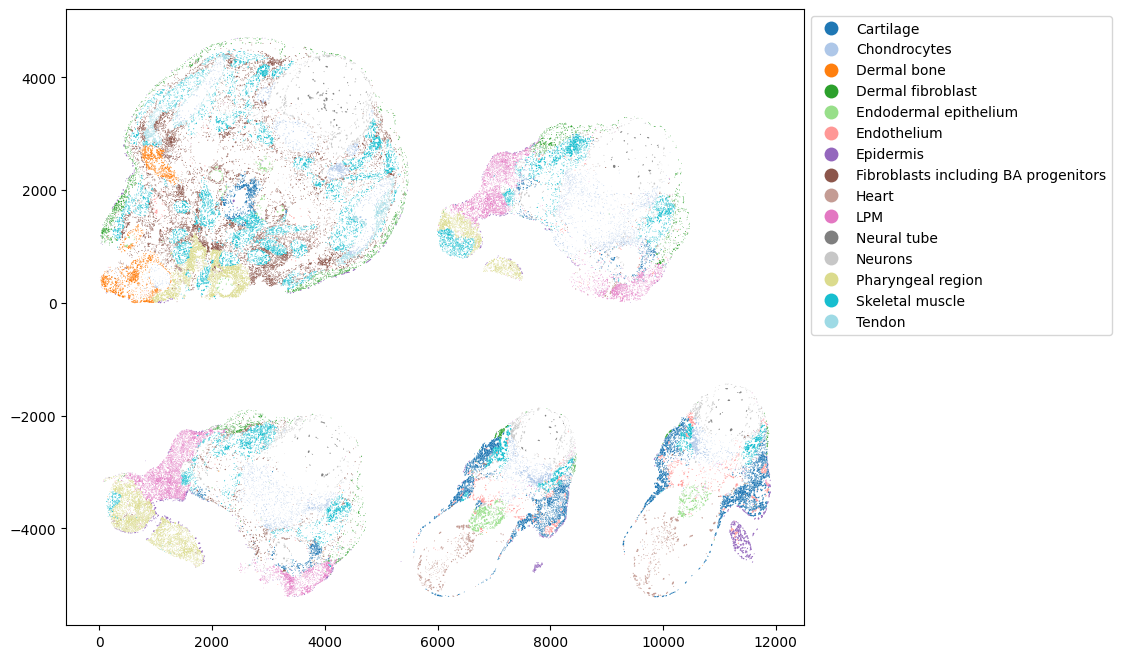

In [79]:
fig, ax = plt.subplots(figsize=(110, 8))
shapes_pdgfra.plot(column='cell_type_labels', cmap='tab20', ax=ax, legend=True, legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})

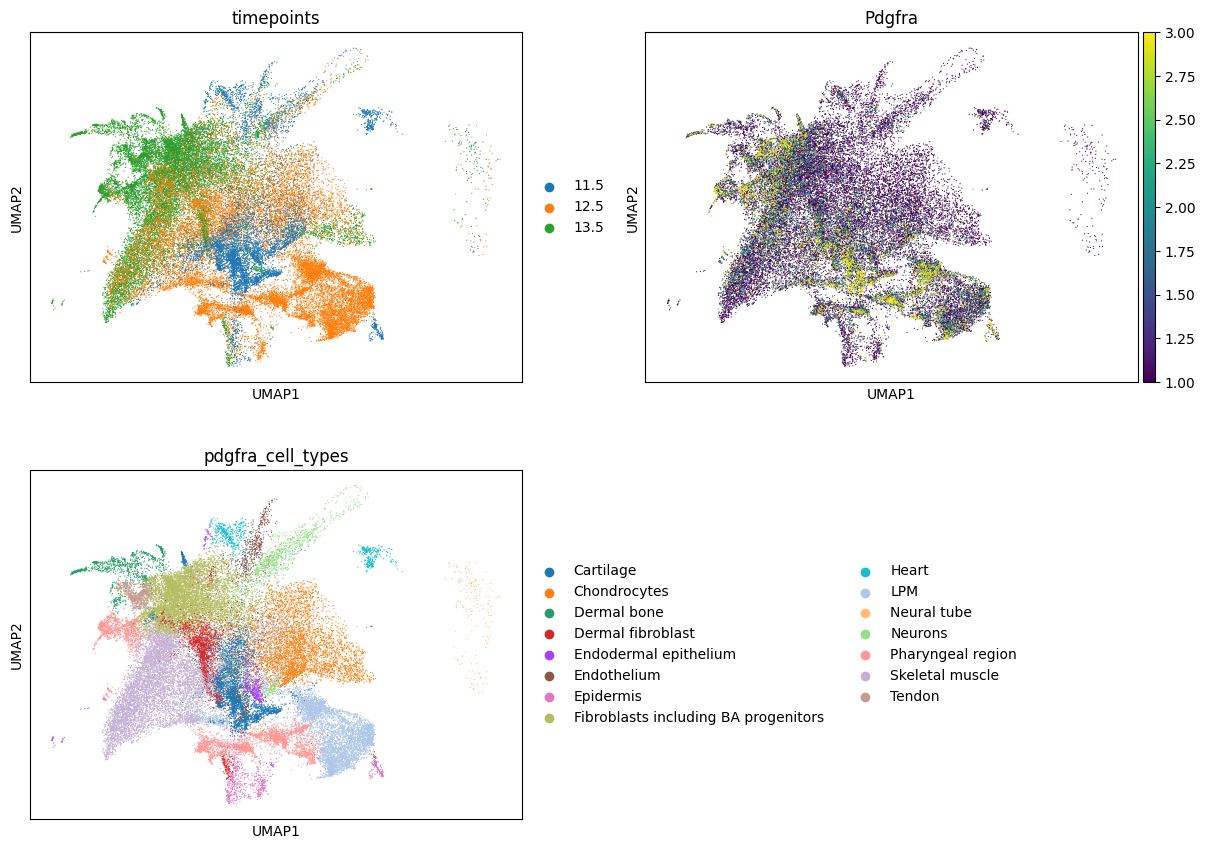

In [83]:
# original umap before recalculating coordinates
sc.pl.umap(pdgfra, color=['timepoints', 'Pdgfra', 'pdgfra_cell_types'], ncols=2, vmax=3)

In [ ]:
# rerun pca
sc.pp.pca(pdgfra, n_comps=50)
# rerun harmony
sce.pp.harmony_integrate(pdgfra, key="sample", basis="X_pca", max_iter_harmony=20)
# rerun neighbors + umap
sc.pp.neighbors(pdgfra, use_rep="X_pca_harmony")
sc.tl.umap(pdgfra, random_state=0)

In [ ]:
sc.pl.umap(pdgfra, color=['timepoints', 'pdgfra_cell_types', 'sample'], ncols=2, frameon=False)

In [ ]:
sc.tl.rank_genes_groups(pdgfra, groupby='pdgfra_cell_types', use_raw=False, method='wilcoxon', key_added='pdgfra_degs')

In [ ]:
sc.pl.rank_genes_groups(pdgfra, key='pdgfra_degs')

In [ ]:
sc.pl.umap(pdgfra, color=['timepoints', 'pdgfra_cell_types'])

In [ ]:
sc.pl.umap(pdgfra, color=['Pparg', 'Cebpa', 'Gata6', 'Cdh4', 'Sox9', 'Col2a1'], vmax=1, color_map='Blues')

### pdgfra+ (pick out clusters)

In [92]:
mask2 = (
    (pdgfra.obs['cell_type_labels'] == 'Cartilage') |
    (pdgfra.obs['cell_type_labels'] == 'LPM') |
    (pdgfra.obs['cell_type_labels'] == 'Tendon') |
    (pdgfra.obs['cell_type_labels'] == 'Dermal fibroblast') |
    (pdgfra.obs['cell_type_labels'] == 'Fibroblasts including BA progenitors') |
    (pdgfra.obs['cell_type_labels'] == 'Chondrocytes') |
    (pdgfra.obs['cell_type_labels'] == 'Dermal bone')
)
adata_pdgfra_clusters = pdgfra[mask2].copy()
adata_pdgfra_clusters

AnnData object with n_obs × n_vars = 26016 × 18262
    obs: 'sample', 'instance_id', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden_harmony_0.6', 'leiden_harmony_0.7', 'cell_type', 'cell_type_labels', 'ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-', 'ebf2_sox9_col2a1', 'fpdev_reclustered_leiden_0.4', 'fpdev_reclustered_leiden_0.5', 'fpdev_reclustered_leiden_0.6', 'tdtom_reclustered_leiden_0.4', 'tdtom_reclustered_leiden_0.5', 'tdtom_reclustered_leiden_0.6', 'pdgfra', 'array_col', 'array_row', 'geometry', 'timepoints', 'tissue', 'cell_type_tdtom_0.4', 'pdgfra+', 'ebf2_sox9_pdgfra', 'pdgfra_cell_types', 'tdtom_0.6_cell_types', 'tdtomato+', 'pdgfra+_tdtomato+'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'cell_type_tdtom_0.6_colors', 'ebf2_sox9_col2a1_color

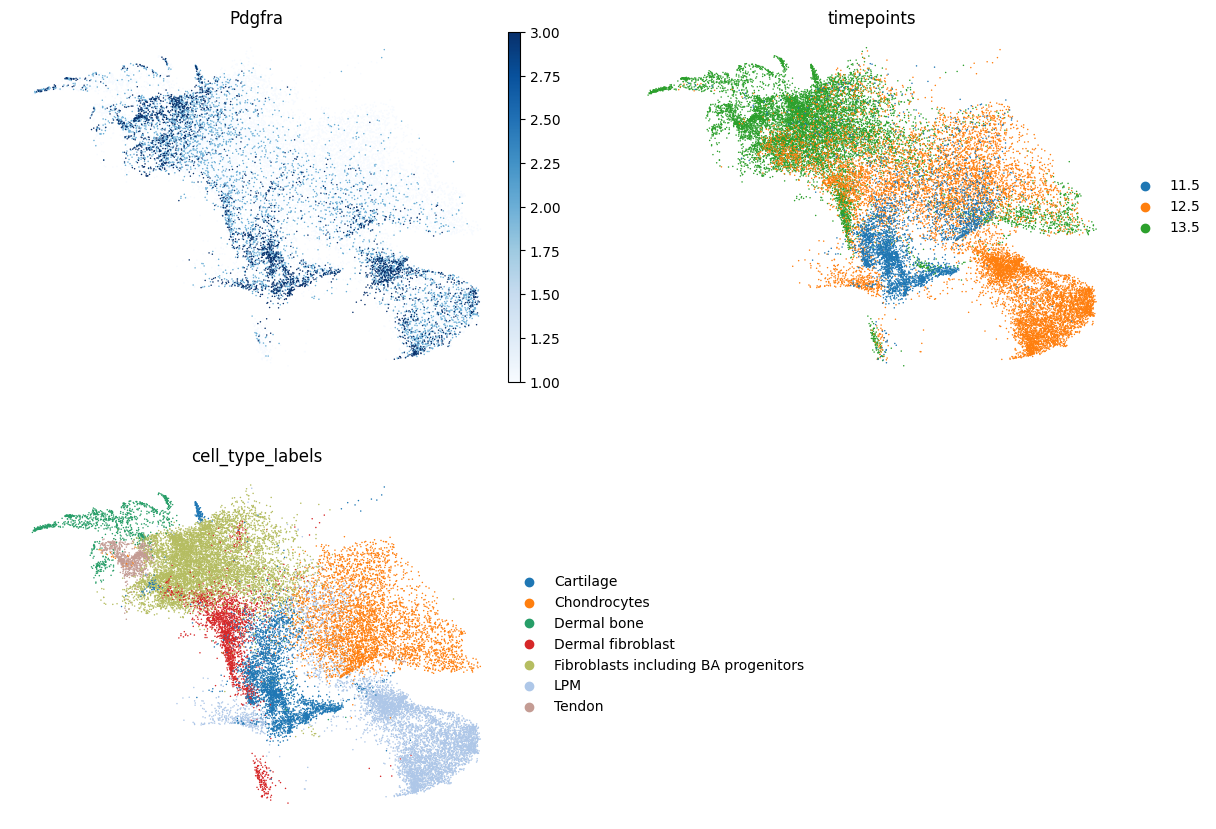

In [96]:
sc.pl.umap(adata_pdgfra_clusters, color=['Pdgfra', 'timepoints', 'cell_type_labels'], ncols=2, vmax=3, color_map='Blues', frameon=False)

In [97]:
# recalculate coordinates
sc.tl.pca(adata_pdgfra_clusters, n_comps=30)
# rerun harmony
sce.pp.harmony_integrate(adata_pdgfra_clusters, key="sample", basis="X_pca", max_iter_harmony=20)
sc.pp.neighbors(adata_pdgfra_clusters, use_rep='X_pca_harmony')
sc.tl.umap(adata_pdgfra_clusters, random_state=42)

2026-04-11 10:34:06,562 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-11 10:34:09,161 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-11 10:34:09,336 - harmonypy - INFO - Iteration 1 of 20
2026-04-11 10:34:12,690 - harmonypy - INFO - Iteration 2 of 20
2026-04-11 10:34:16,210 - harmonypy - INFO - Converged after 2 iterations


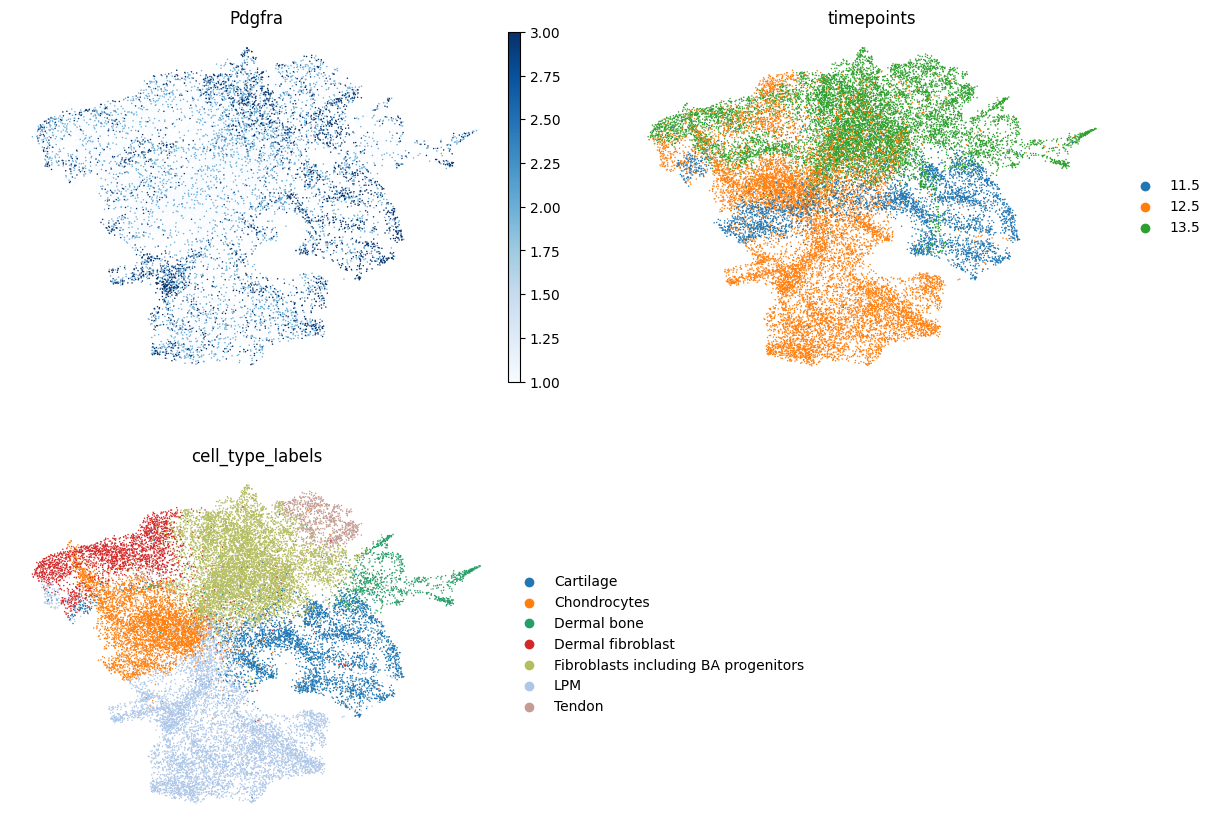

: 

In [ ]:
sc.pl.umap(adata_pdgfra_clusters, color=['Pdgfra', 'timepoints', 'cell_type_labels'], color_map='Blues', vmax=3, ncols=2, frameon=False)

## tdtom

In [ ]:
mask_tdtom = adata.obs['tdtomato+'] == True
tdtom = adata[mask_tdtom].copy()
tdtom

In [ ]:
shapes_tdtom = gpd.GeoDataFrame(tdtom.obs, geometry='geometry')

In [ ]:
fig, ax = plt.subplots(figsize=(14, 12))
shapes_tdtom.plot(column='cell_type_labels', cmap='tab20', ax=ax, legend=True, legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})

In [ ]:
sc.pl.umap(tdtom, color=['timepoints', 'cell_type_labels', 'sample'], ncols=2)

In [ ]:
# rerun pca
sc.pp.pca(tdtom, n_comps=50)
# rerun harmony
sce.pp.harmony_integrate(tdtom, key="sample", basis="X_pca", max_iter_harmony=20)
# rerun neighbors + umap
sc.pp.neighbors(tdtom, use_rep="X_pca_harmony")
sc.tl.umap(tdtom, random_state=0)

In [ ]:
sc.pl.umap(tdtom, color=['timepoints', 'cell_type_labels', 'sample'], ncols=2, frameon=False)